ARTI308 - Machine Learning
# Seaborn Overview

Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.




## Distribution Plots

Let's discuss some plots that allow us to visualize the distribution of a data set. These plots are:

* distplot
* jointplot
* pairplot
* rugplot
* kdeplot

## Imports

In [2]:
import seaborn as sns # Import Seaborn library for statistical data visualization

## Data
Seaborn comes with built-in data sets!

In [59]:
tips = sns.load_dataset('tips') # Load the built-in 'tips' dataset from Seaborn

In [60]:
tips.head() # Display the first five rows of the tips dataframe

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## distplot

The distplot shows the distribution of a univariate set of observations.

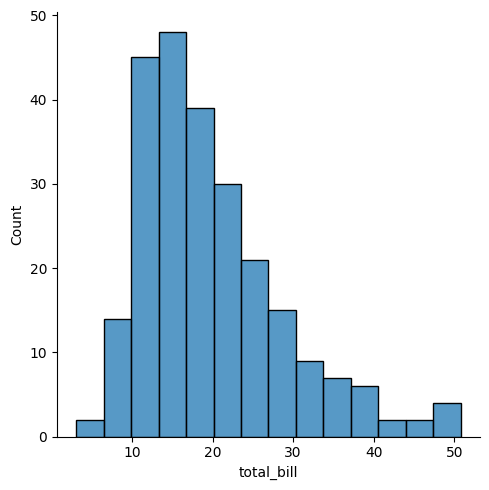

In [61]:
sns.displot(tips['total_bill']) # Plot a univariate distribution of observations
# Safe to ignore warnings

To remove the kde layer and just have the histogram use:

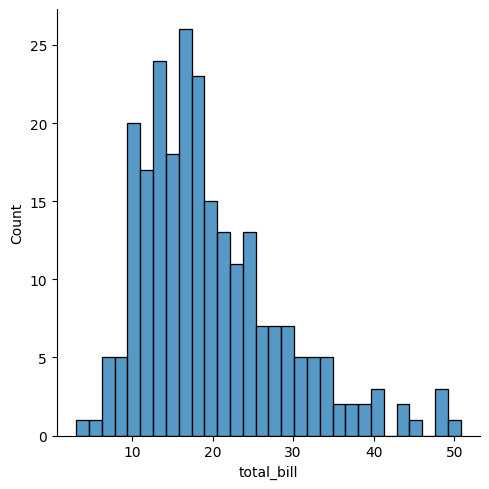

In [62]:
sns.displot(tips['total_bill'],kde=False,bins=30) # Plot a univariate distribution of observations

## jointplot

jointplot() allows you to basically match up two distplots for bivariate data. With your choice of what **kind** parameter to compare with: 
* “scatter” 
* “reg” 
* “resid” 
* “kde” 
* “hex”

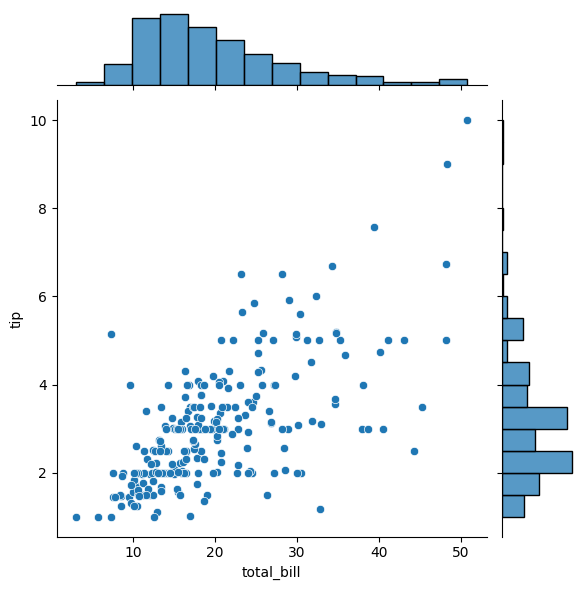

In [63]:
sns.jointplot(x='total_bill',y='tip',data=tips,kind='scatter') # Plot bivariate and univariate graphs for two variables

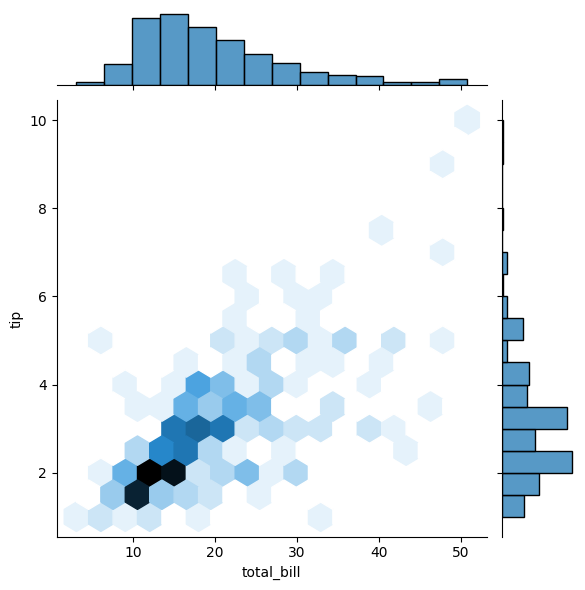

In [64]:
sns.jointplot(x='total_bill',y='tip',data=tips,kind='hex') # Plot bivariate and univariate graphs for two variables

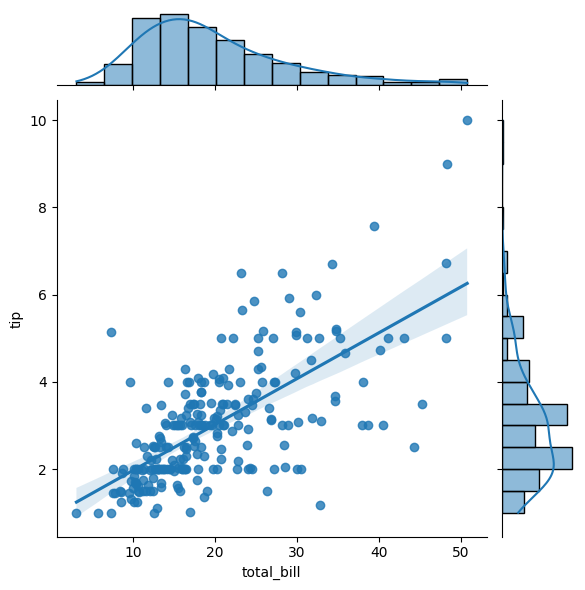

In [65]:
sns.jointplot(x='total_bill',y='tip',data=tips,kind='reg') # Plot bivariate and univariate graphs for two variables

## pairplot

pairplot will plot pairwise relationships across an entire dataframe (for the numerical columns) and supports a color hue argument (for categorical columns). 

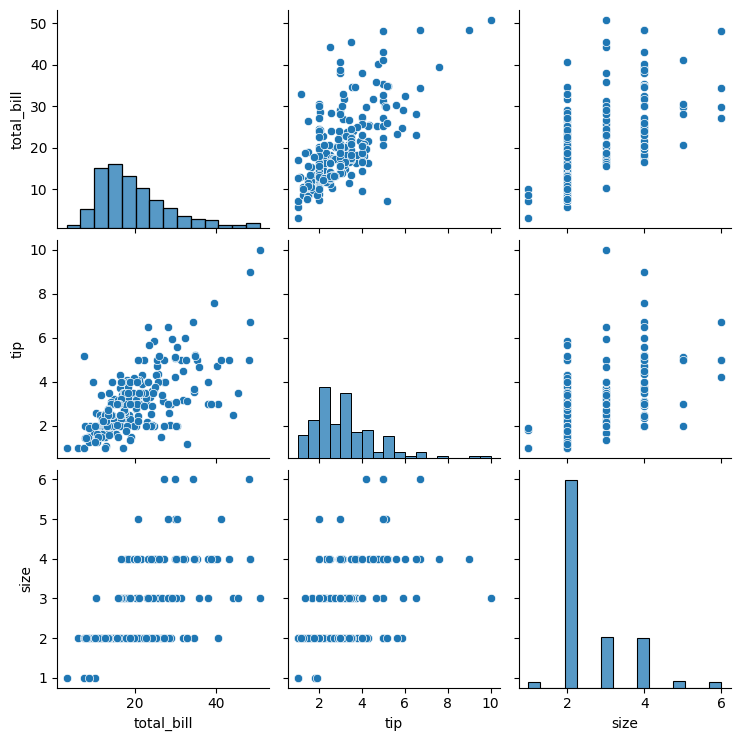

In [66]:
sns.pairplot(tips) # Plot pairwise relationships across the entire dataframe

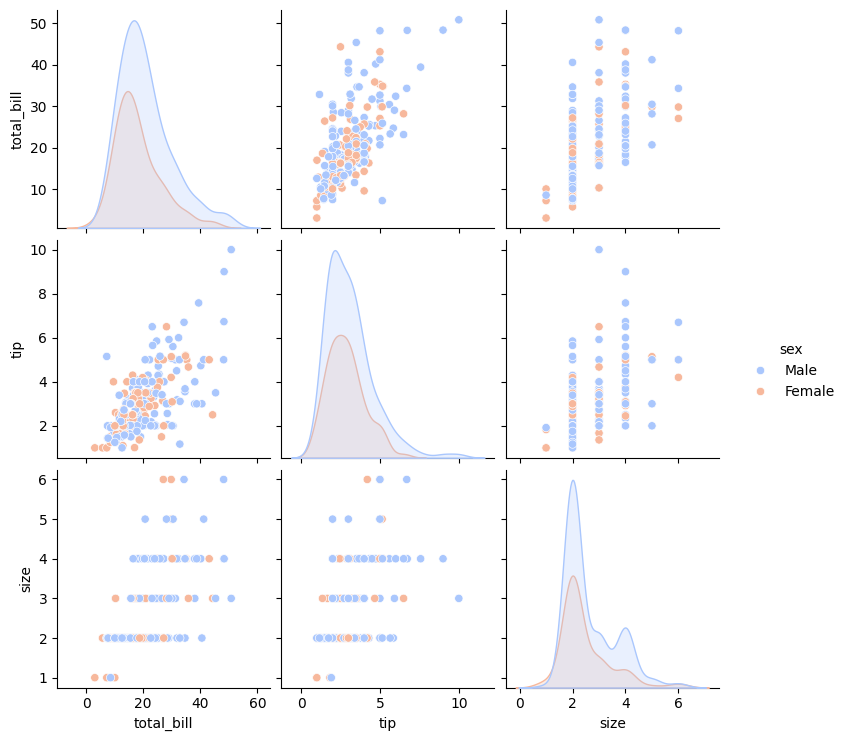

In [67]:
sns.pairplot(tips,hue='sex',palette='coolwarm') # Plot pairwise relationships across the entire dataframe

## rugplot

rugplots are actually a very simple concept, they just draw a dash mark for every point on a univariate distribution. They are the building block of a KDE plot:

<Axes: xlabel='total_bill'>

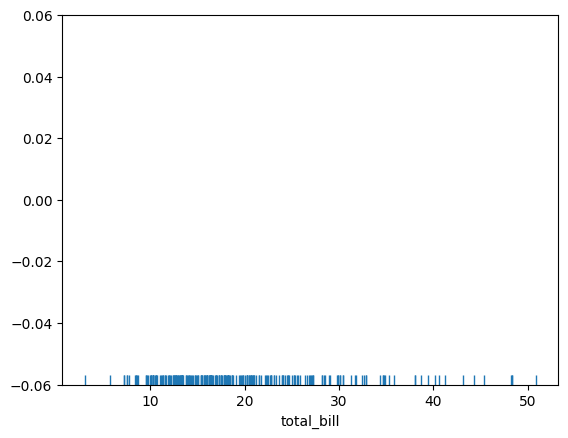

In [68]:
sns.rugplot(tips['total_bill']) # Draw small vertical ticks at each observation point

## kdeplot

kdeplots are [Kernel Density Estimation plots](http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth). These KDE plots replace every single observation with a Gaussian (Normal) distribution centered around that value. For example:

(0.0, 1.0)

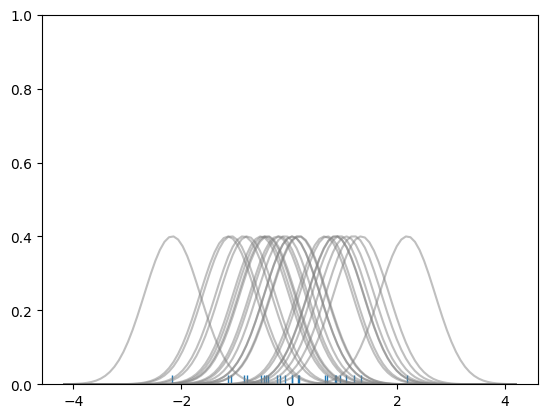

In [69]:
# Don't worry about understanding this code!
# It's just for the diagram below
import numpy as np # Import NumPy library for numerical operations
import matplotlib.pyplot as plt # Import Matplotlib library for plotting
from scipy import stats # Import stats module from SciPy library

#Create dataset
dataset = np.random.randn(25) # Generate a sample from the standard normal distribution

# Create another rugplot
sns.rugplot(dataset); # Draw small vertical ticks at each observation point

# Set up the x-axis for the plot
x_min = dataset.min() - 2 # Display the value of x
x_max = dataset.max() + 2 # Display the value of x

# 100 equally spaced points from x_min to x_max
x_axis = np.linspace(x_min,x_max,100) # Define the x-axis values

# Set up the bandwidth, for info on this:
url = 'http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth'

bandwidth = ((4*dataset.std()**5)/(3*len(dataset)))**.2 # Calculate the bandwidth for KDE


# Create an empty kernel list
kernel_list = [] # Initialize a list to store kernels

# Plot each basis function
for data_point in dataset: # Iterate through each data point in the dataset
    
    # Create a kernel for each point and append to list
    kernel = stats.norm(data_point,bandwidth).pdf(x_axis) # Define the kernel function for a point
    kernel_list.append(kernel) # Add the calculated kernel to the list
    
    #Scale for plotting
    kernel = kernel / kernel.max() # Define the kernel function for a point
    kernel = kernel * .4 # Define the kernel function for a point
    plt.plot(x_axis,kernel,color = 'grey',alpha=0.5) # Create a line plot

plt.ylim(0,1) # Display the value of y

Text(0.5, 0.98, 'Sum of the Basis Functions')

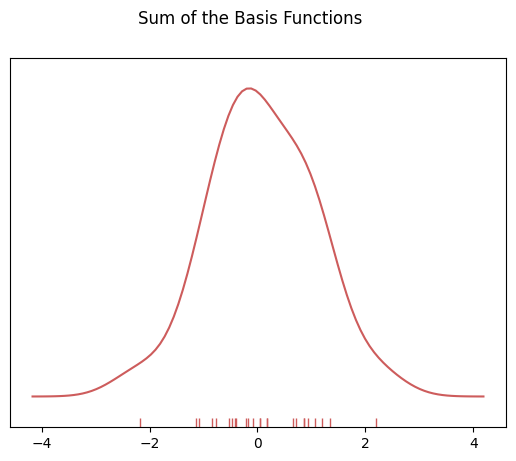

In [70]:
# To get the kde plot we can sum these basis functions.

# Plot the sum of the basis function
sum_of_kde = np.sum(kernel_list,axis=0) # Calculate the sum of array elements

# Plot figure
fig = plt.plot(x_axis,sum_of_kde,color='indianred') # Create a line plot

# Add the initial rugplot
sns.rugplot(dataset,c = 'indianred') # Draw small vertical ticks at each observation point

# Get rid of y-tick marks
plt.yticks([]) # Remove y-axis tick marks

# Set title
plt.suptitle("Sum of the Basis Functions") # Set a centered title for the figure

So with our tips dataset:

<Axes: xlabel='total_bill', ylabel='Density'>

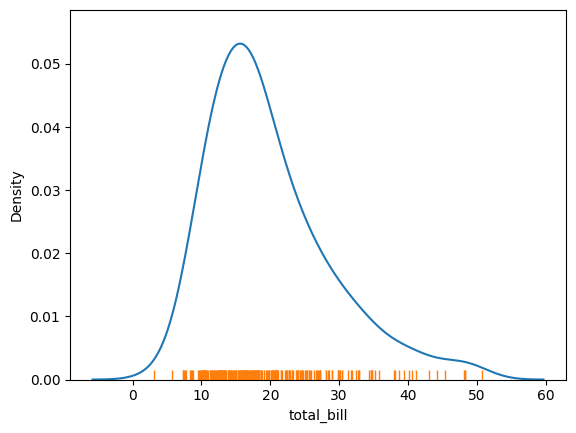

In [71]:
sns.kdeplot(tips['total_bill']) # Plot a kernel density estimate for the data
sns.rugplot(tips['total_bill']) # Draw small vertical ticks at each observation point

<Axes: xlabel='tip', ylabel='Density'>

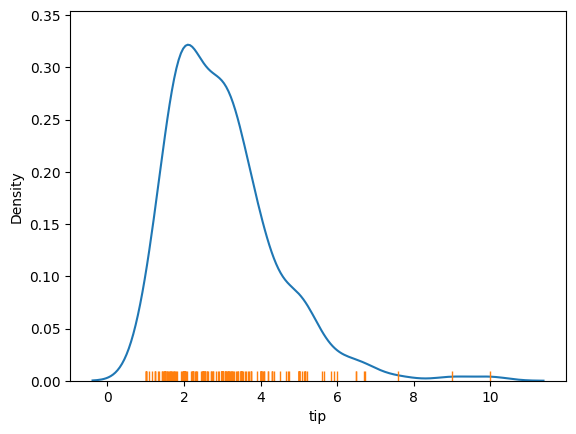

In [72]:
sns.kdeplot(tips['tip']) # Plot a kernel density estimate for the data
sns.rugplot(tips['tip']) # Draw small vertical ticks at each observation point

# Categorical Data Plots

Now let's discuss using seaborn to plot categorical data! There are a few main plot types for this:

* factorplot
* boxplot
* violinplot
* stripplot
* swarmplot
* barplot
* countplot

Let's go through examples of each!

In [73]:
import seaborn as sns # Import Seaborn library for statistical data visualization

In [74]:
tips = sns.load_dataset('tips') # Load the built-in 'tips' dataset from Seaborn
tips.head() # Display the first five rows of the tips dataframe

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## barplot and countplot

These very similar plots allow you to get aggregate data off a categorical feature in your data. **barplot** is a general plot that allows you to aggregate the categorical data based off some function, by default the mean:

<Axes: xlabel='sex', ylabel='total_bill'>

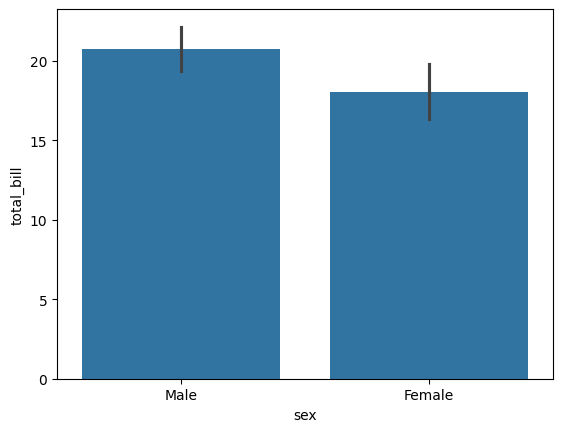

In [75]:
sns.barplot(x='sex',y='total_bill',data=tips) # Create a bar plot to show aggregate categorical data

In [76]:
import numpy as np # Import NumPy library for numerical operations

You can change the estimator object to your own function, that converts a vector to a scalar:

<Axes: xlabel='sex', ylabel='total_bill'>

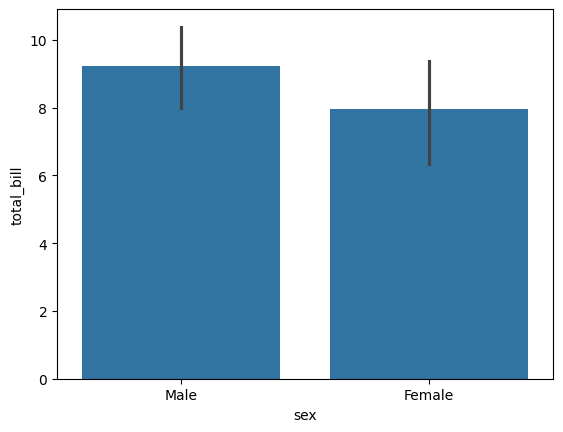

In [77]:
sns.barplot(x='sex',y='total_bill',data=tips,estimator=np.std) # Create a bar plot to show aggregate categorical data

### countplot

This is essentially the same as barplot except the estimator is explicitly counting the number of occurrences. Which is why we only pass the x value:

<Axes: xlabel='sex', ylabel='count'>

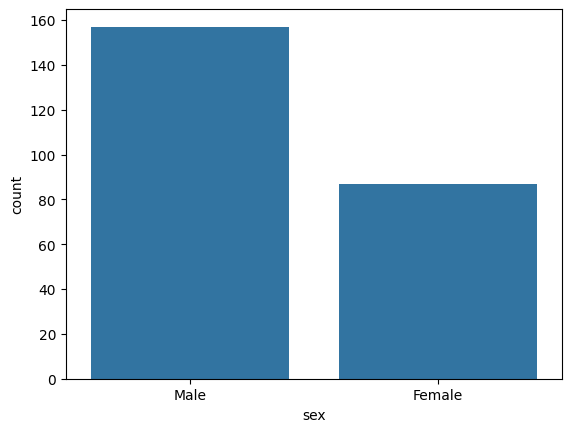

In [78]:
sns.countplot(x='sex',data=tips) # Show the count of occurrences for each category

## boxplot and violinplot

boxplots and violinplots are used to shown the distribution of categorical data. A box plot (or box-and-whisker plot) shows the distribution of quantitative data in a way that facilitates comparisons between variables or across levels of a categorical variable. The box shows the quartiles of the dataset while the whiskers extend to show the rest of the distribution, except for points that are determined to be “outliers” using a method that is a function of the inter-quartile range.

C:\Users\x1Ras\AppData\Local\Temp\ipykernel_29256\911917381.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="day", y="total_bill", data=tips,palette='rainbow') # Draw a box plot to show the distribution of categorical data


<Axes: xlabel='day', ylabel='total_bill'>

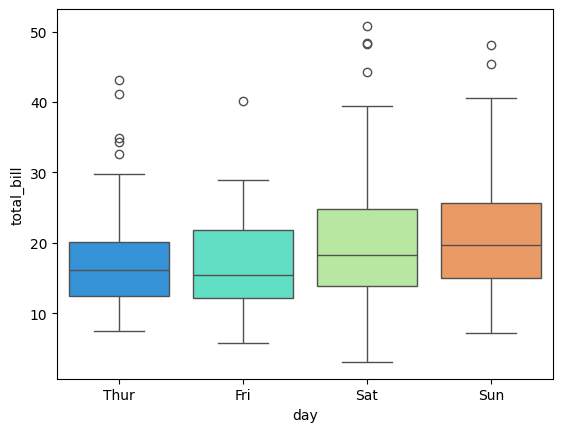

In [79]:
sns.boxplot(x="day", y="total_bill", data=tips,palette='rainbow') # Draw a box plot to show the distribution of categorical data

<Axes: >

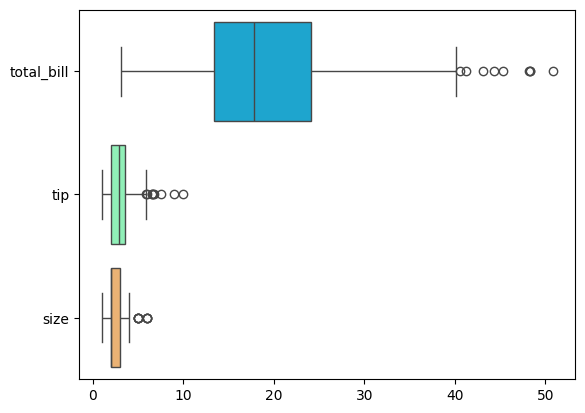

In [80]:
# Can do entire dataframe with orient='h'
sns.boxplot(data=tips,palette='rainbow',orient='h') # Draw a box plot to show the distribution of categorical data

<Axes: xlabel='day', ylabel='total_bill'>

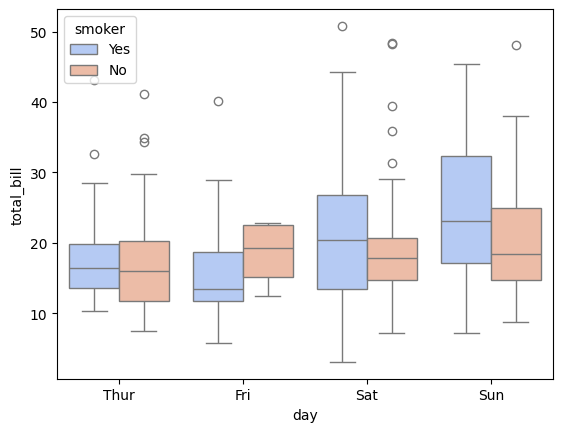

In [81]:
sns.boxplot(x="day", y="total_bill", hue="smoker",data=tips, palette="coolwarm") # Draw a box plot to show the distribution of categorical data

### violinplot
A violin plot plays a similar role as a box and whisker plot. It shows the distribution of quantitative data across several levels of one (or more) categorical variables such that those distributions can be compared. Unlike a box plot, in which all of the plot components correspond to actual datapoints, the violin plot features a kernel density estimation of the underlying distribution.

C:\Users\x1Ras\AppData\Local\Temp\ipykernel_29256\1506359430.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="day", y="total_bill", data=tips,palette='rainbow') # Draw a violin plot to show distribution density


<Axes: xlabel='day', ylabel='total_bill'>

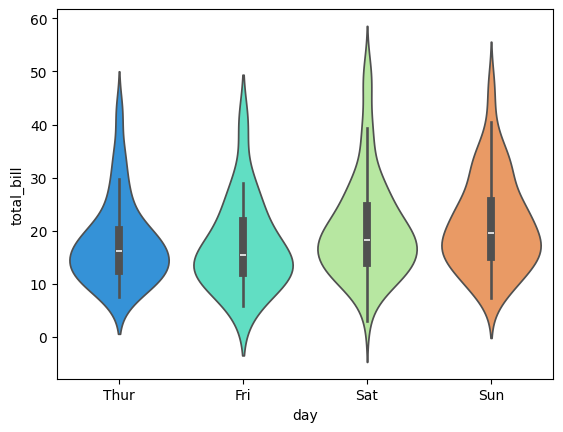

In [82]:
sns.violinplot(x="day", y="total_bill", data=tips,palette='rainbow') # Draw a violin plot to show distribution density

<Axes: xlabel='day', ylabel='total_bill'>

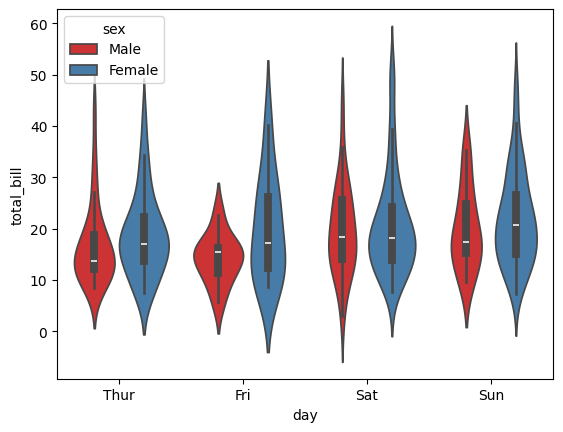

In [83]:
sns.violinplot(x="day", y="total_bill", data=tips,hue='sex',palette='Set1') # Draw a violin plot to show distribution density

<Axes: xlabel='day', ylabel='total_bill'>

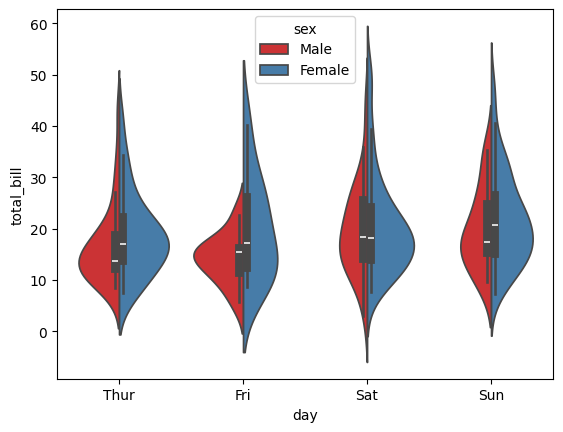

In [84]:
sns.violinplot(x="day", y="total_bill", data=tips,hue='sex',split=True,palette='Set1') # Draw a violin plot to show distribution density

## stripplot and swarmplot
The stripplot will draw a scatterplot where one variable is categorical. A strip plot can be drawn on its own, but it is also a good complement to a box or violin plot in cases where you want to show all observations along with some representation of the underlying distribution.

The swarmplot is similar to stripplot(), but the points are adjusted (only along the categorical axis) so that they don’t overlap. This gives a better representation of the distribution of values, although it does not scale as well to large numbers of observations (both in terms of the ability to show all the points and in terms of the computation needed to arrange them).

C:\Users\x1Ras\AppData\Local\Temp\ipykernel_29256\935985848.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="day", y="total_bill", data=tips, palette='rainbow') # Draw a scatterplot where one variable is categorical


<Axes: xlabel='day', ylabel='total_bill'>

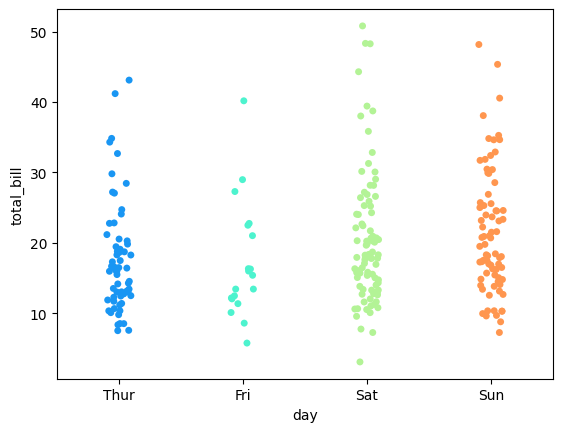

In [85]:
sns.stripplot(x="day", y="total_bill", data=tips, palette='rainbow') # Draw a scatterplot where one variable is categorical

C:\Users\x1Ras\AppData\Local\Temp\ipykernel_29256\2509117289.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="day", y="total_bill", data=tips,jitter=True, palette='rainbow') # Draw a scatterplot where one variable is categorical


<Axes: xlabel='day', ylabel='total_bill'>

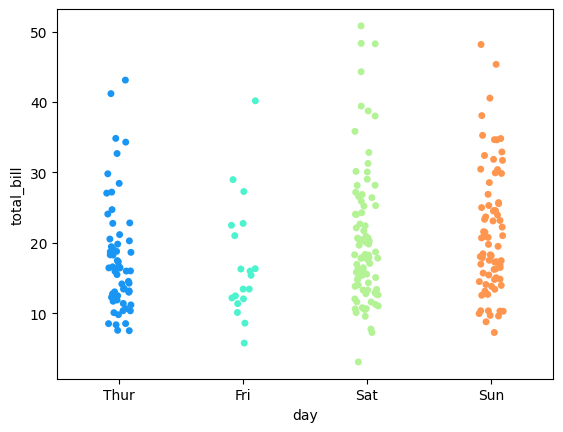

In [86]:
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True, palette='rainbow') # Draw a scatterplot where one variable is categorical

<Axes: xlabel='day', ylabel='total_bill'>

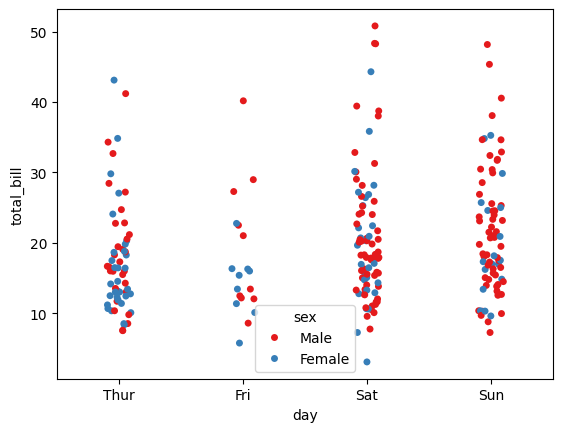

In [87]:
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True,hue='sex',palette='Set1') # Draw a scatterplot where one variable is categorical

<Axes: xlabel='day', ylabel='total_bill'>

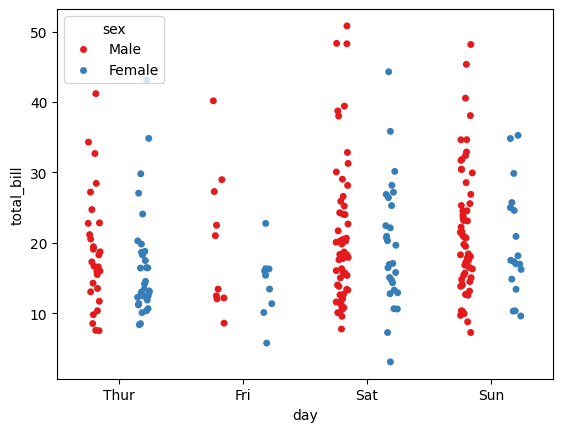

In [88]:
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True,hue='sex',palette='Set1',dodge=True) # Draw a scatterplot where one variable is categorical

<Axes: xlabel='day', ylabel='total_bill'>

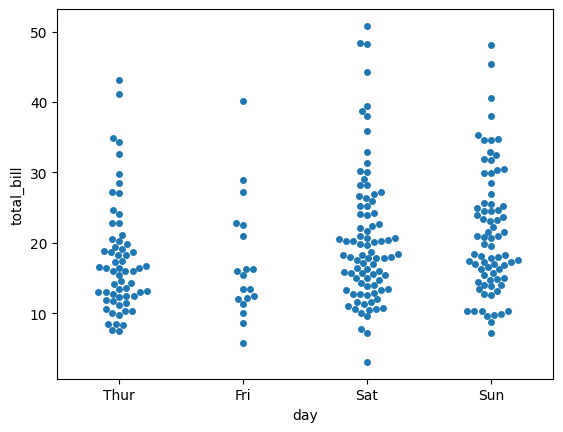

In [89]:
sns.swarmplot(x="day", y="total_bill", data=tips) # Draw a categorical scatterplot with non-overlapping points

### Combining Categorical Plots

C:\Users\x1Ras\AppData\Local\Temp\ipykernel_29256\528121805.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="tip", y="day", data=tips,palette='rainbow') # Draw a violin plot to show distribution density


<Axes: xlabel='tip', ylabel='day'>

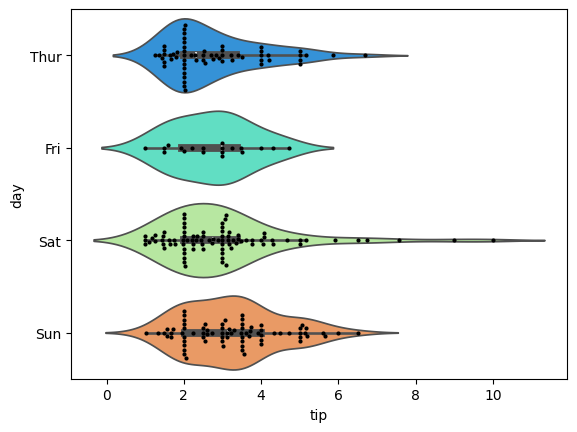

In [90]:
sns.violinplot(x="tip", y="day", data=tips,palette='rainbow') # Draw a violin plot to show distribution density
sns.swarmplot(x="tip", y="day", data=tips,color='black',size=3) # Draw a categorical scatterplot with non-overlapping points

## catplot

factorplot is the most general form of a categorical plot. It can take in a kind parameter to adjust the plot type:

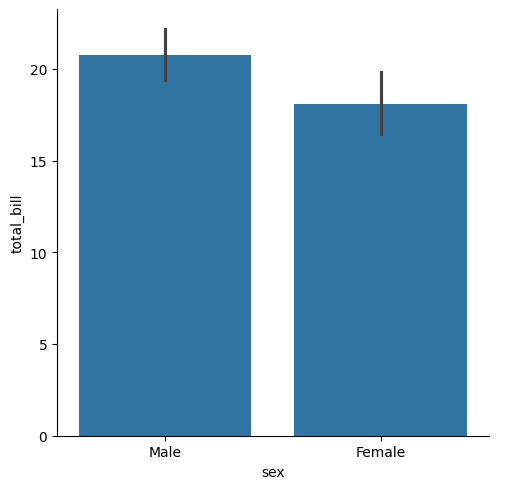

In [91]:
sns.catplot(x='sex',y='total_bill',data=tips,kind='bar') # Create figure-level plots on categorical data

# Matrix Plots

Matrix plots allow you to plot data as color-encoded matrices and can also be used to indicate clusters within the data (later in the machine learning section we will learn how to formally cluster data).

Let's begin by exploring seaborn's heatmap and clutermap:

In [92]:
import seaborn as sns # Import Seaborn library for statistical data visualization

In [93]:
flights = sns.load_dataset('flights') # Load the built-in 'flights' dataset from Seaborn

In [94]:
tips = sns.load_dataset('tips') # Load the built-in 'tips' dataset from Seaborn

In [95]:
tips.head() # Display the first five rows of the tips dataframe

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [96]:
flights.head() # Display the first five rows of the flights dataframe

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


## Heatmap

In order for a heatmap to work properly, your data should already be in a matrix form, the sns.heatmap function basically just colors it in for you. For example:

In [97]:
tips.head() # Display the first five rows of the tips dataframe

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [98]:
# Matrix form for correlation data
tips.corr() # Calculate the correlation matrix for the tips dataset

ValueError: could not convert string to float: 'Female'

In [99]:
sns.heatmap(tips.corr()) # Plot rectangular data as a color-encoded matrix

ValueError: could not convert string to float: 'Female'

In [ ]:
sns.heatmap(tips.corr(),cmap='coolwarm',annot=True) # Plot rectangular data as a color-encoded matrix

Or for the flights data:

In [100]:
flights.pivot_table(values='passengers',index='month',columns='year') # Create a pivot table from the flights dataset

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0
Jun,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
Jul,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
Aug,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
Sep,136.0,158.0,184.0,209.0,237.0,259.0,312.0,355.0,404.0,404.0,463.0,508.0


<Axes: xlabel='year', ylabel='month'>

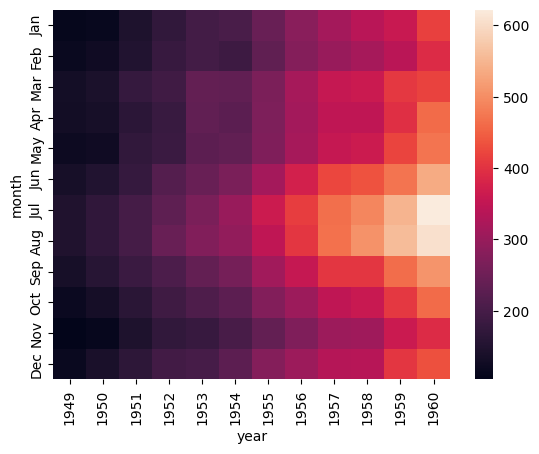

In [101]:
pvflights = flights.pivot_table(values='passengers',index='month',columns='year') # Create a pivot table from the flights dataset
sns.heatmap(pvflights) # Plot rectangular data as a color-encoded matrix

<Axes: xlabel='year', ylabel='month'>

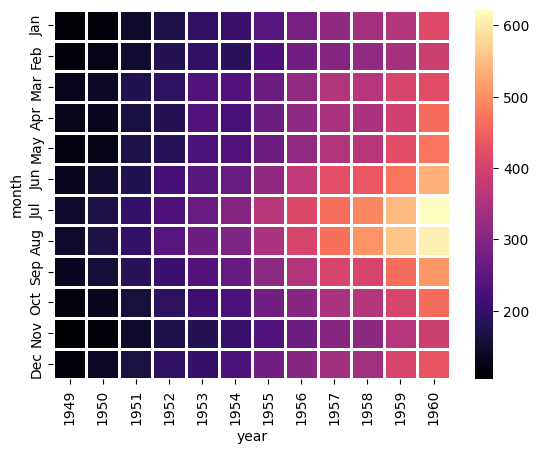

In [102]:
sns.heatmap(pvflights,cmap='magma',linecolor='white',linewidths=1) # Plot rectangular data as a color-encoded matrix

## clustermap

The clustermap uses hierarchal clustering to produce a clustered version of the heatmap. For example:

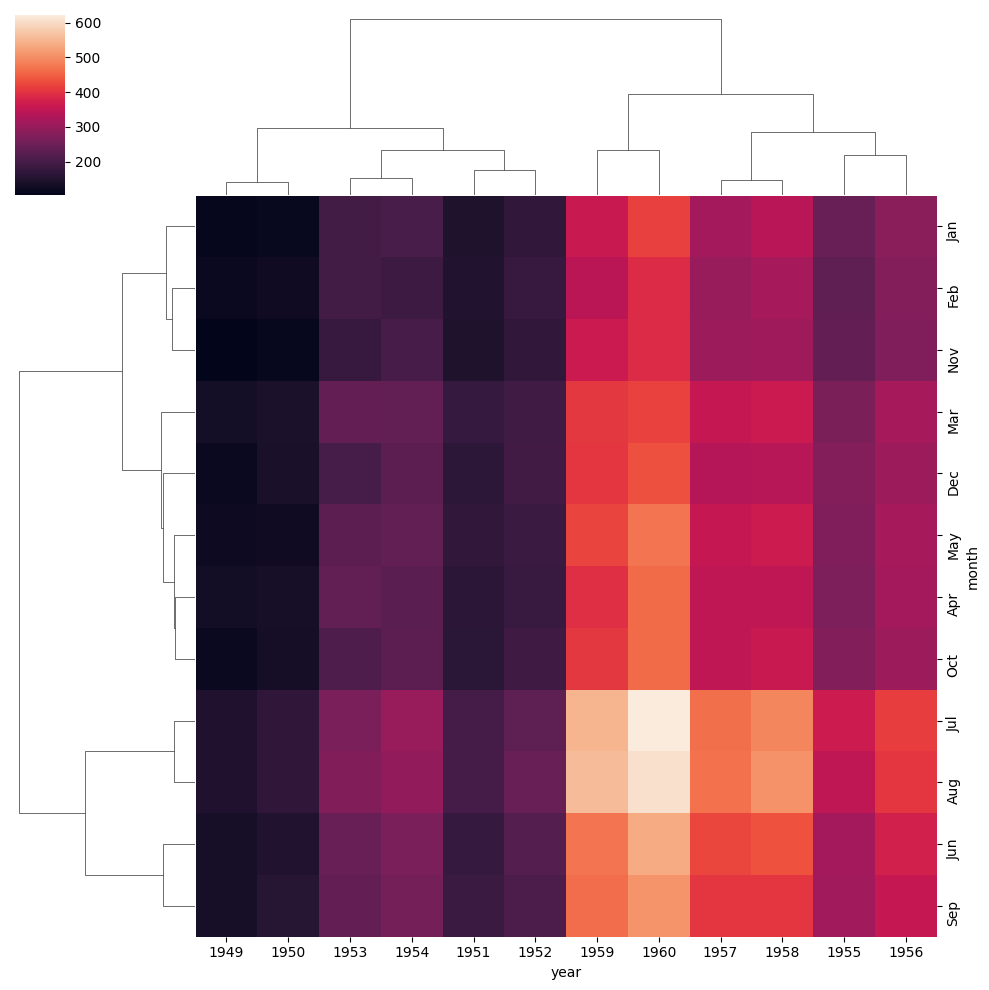

In [103]:
sns.clustermap(pvflights) # Plot a matrix dataset as a hierarchically-clustered heatmap

Notice now how the years and months are no longer in order, instead they are grouped by similarity in value (passenger count). That means we can begin to infer things from this plot, such as August and July being similar (makes sense, since they are both summer travel months)

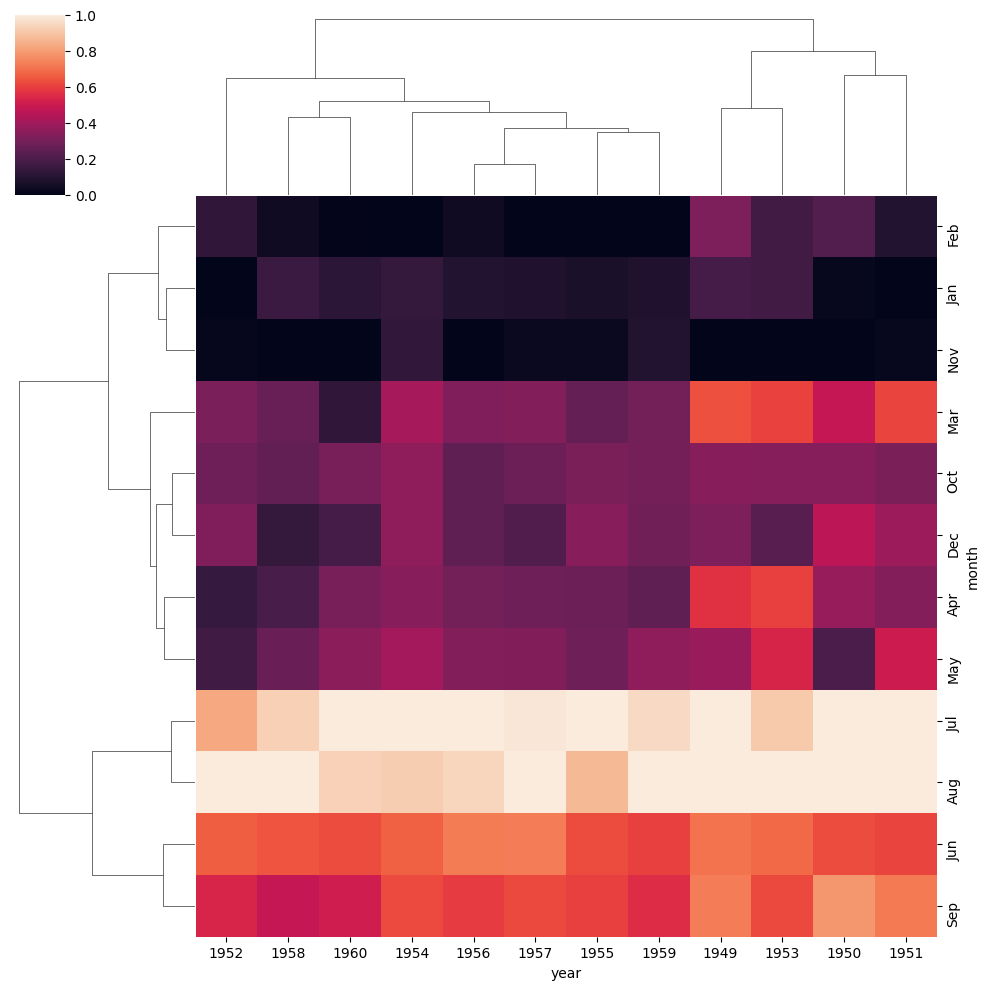

In [104]:
# More options to get the information a little clearer like normalization
sns.clustermap(pvflights,standard_scale=1) # Plot a matrix dataset as a hierarchically-clustered heatmap

# Regression Plots

Seaborn has many built-in capabilities for regression plots, however we won't really discuss regression until the machine learning section of the course, so we will only cover the **lmplot()** function for now.

**lmplot** allows you to display linear models, but it also conveniently allows you to split up those plots based off of features, as well as coloring the hue based off of features.

Let's explore how this works:

In [105]:
import seaborn as sns # Import Seaborn library for statistical data visualization

In [106]:
tips = sns.load_dataset('tips') # Load the built-in 'tips' dataset from Seaborn

In [107]:
tips.head() # Display the first five rows of the tips dataframe

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## lmplot()

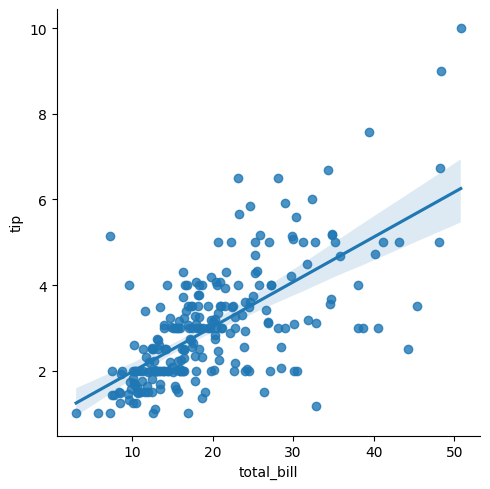

In [108]:
sns.lmplot(x='total_bill',y='tip',data=tips) # Plot data and regression model fits

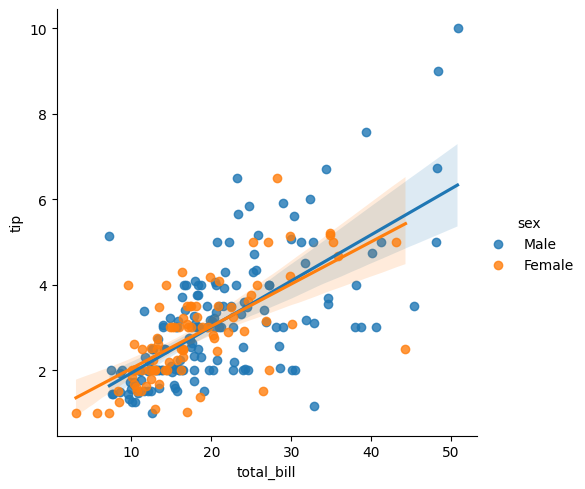

In [109]:
sns.lmplot(x='total_bill',y='tip',data=tips,hue='sex') # Plot data and regression model fits

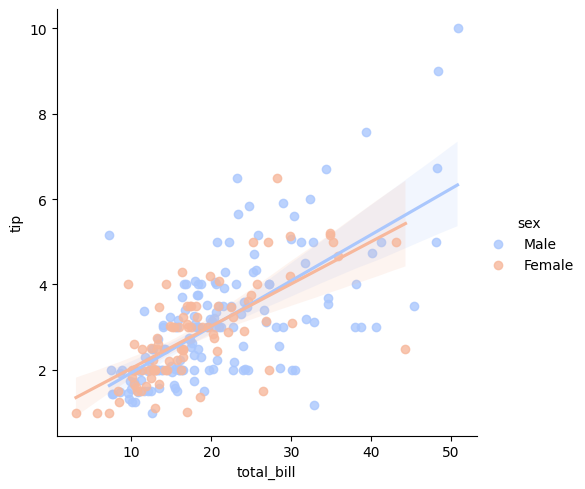

In [110]:
sns.lmplot(x='total_bill',y='tip',data=tips,hue='sex',palette='coolwarm') # Plot data and regression model fits

## Using a Grid

We can add more variable separation through columns and rows with the use of a grid. Just indicate this with the col or row arguments:

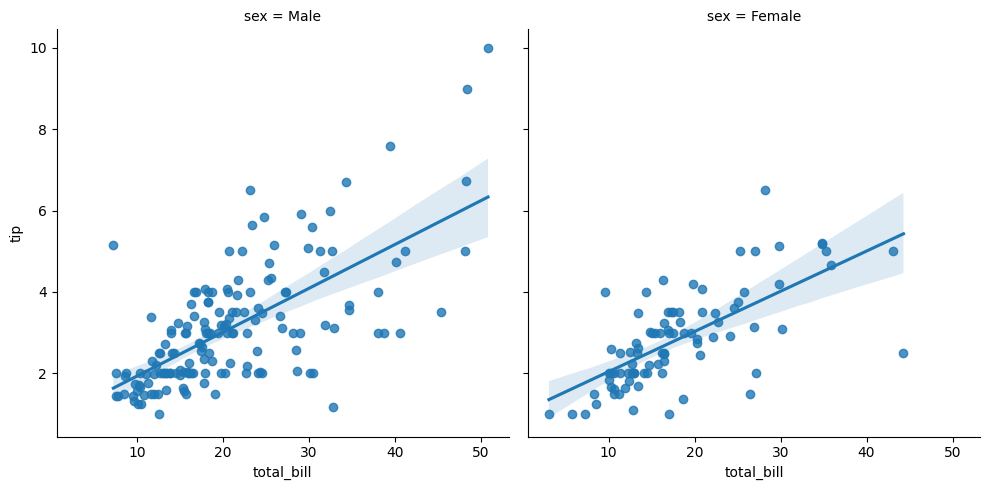

In [111]:
sns.lmplot(x='total_bill',y='tip',data=tips,col='sex') # Plot data and regression model fits

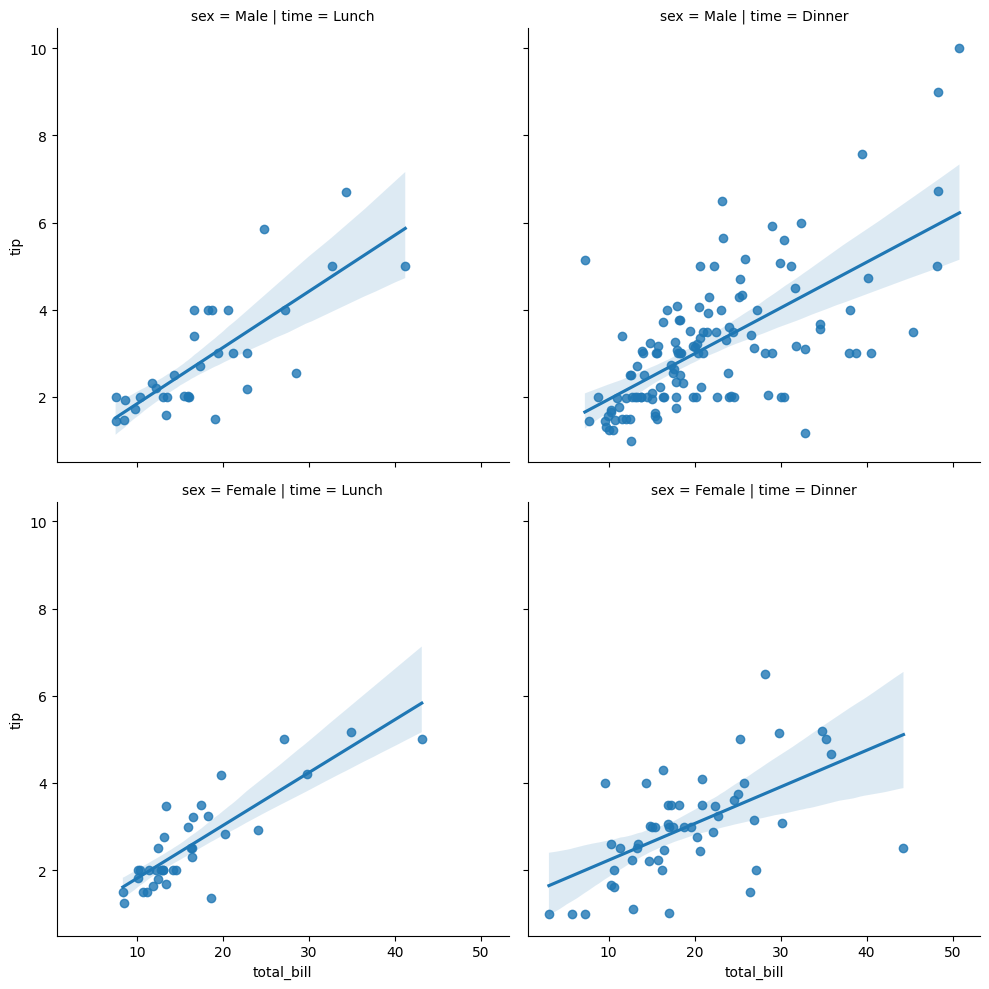

In [112]:
sns.lmplot(x="total_bill", y="tip", row="sex", col="time",data=tips) # Plot data and regression model fits

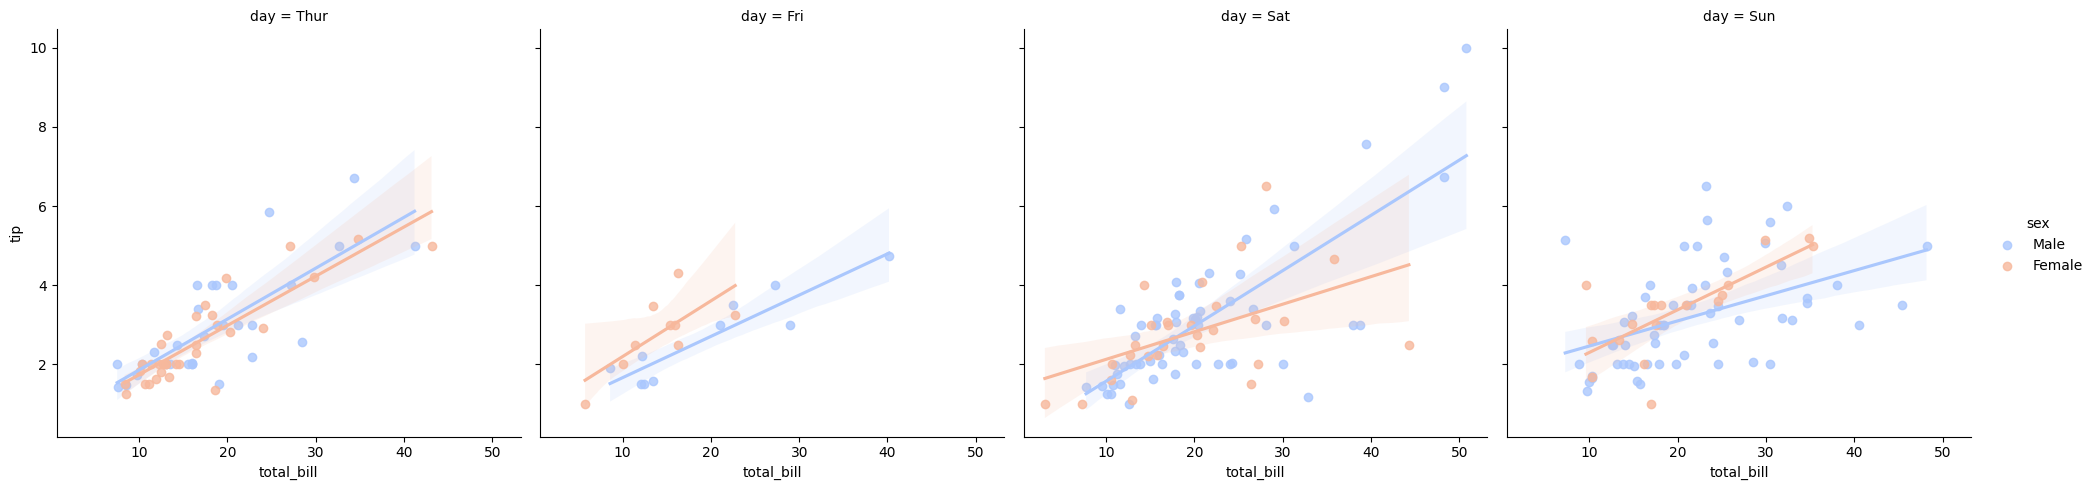

In [113]:
sns.lmplot(x='total_bill',y='tip',data=tips,col='day',hue='sex',palette='coolwarm') # Plot data and regression model fits

## Aspect and Size

Seaborn figures can have their size and aspect ratio adjusted with the **height** and **aspect** parameters:

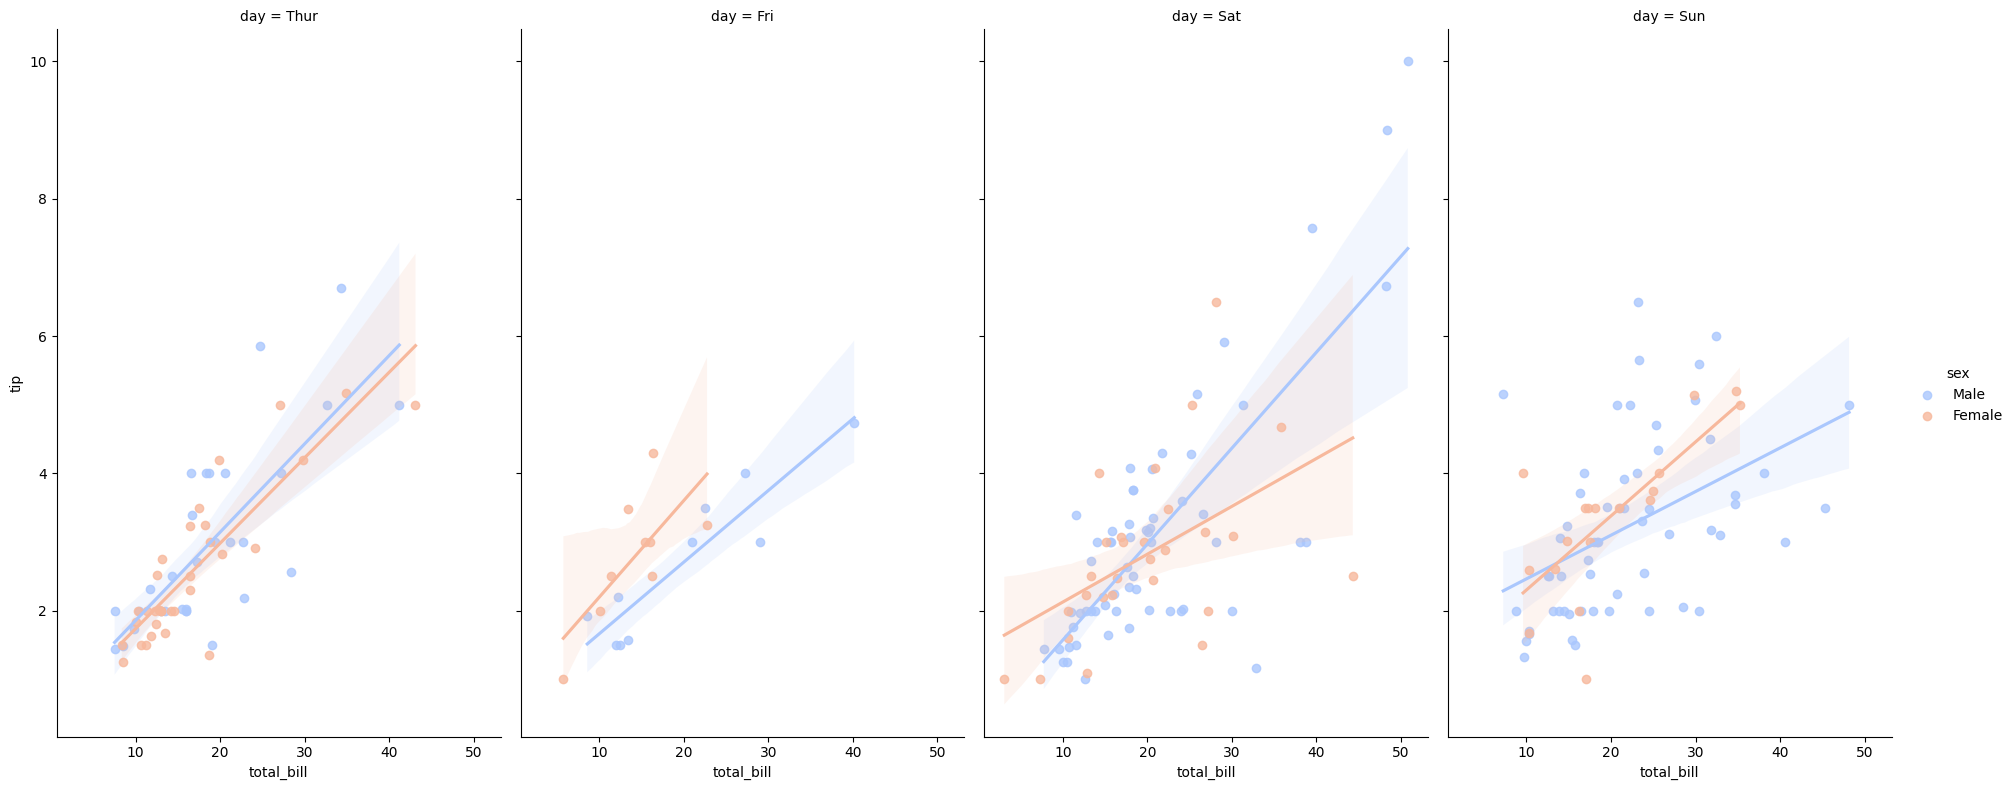

In [114]:
sns.lmplot(x='total_bill',y='tip',data=tips,col='day',hue='sex',palette='coolwarm', # Plot data and regression model fits
          aspect=0.6,height=8) # Execute the line of code

### Reference:

* https://seaborn.pydata.org/ - Seaborn: statistical data visualization


* https://seaborn.pydata.org/tutorial/color_palettes.html - Color palettes